In [1]:
# ------------------------------------------------------------------------------------------
# Cell 0: Environment / Imports / Paths / Plot Settings
# Run this cell first whenever you restart the kernel
# ------------------------------------------------------------------------------------------

# ------------------------------
# Imports
# ------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import pyvista as pv
from scipy.spatial import KDTree

# ------------------------------
# PyVista backend for Jupyter
# ------------------------------
pv.set_jupyter_backend('trame')

# ------------------------------
# Input directory
# ------------------------------
input_vtk_dir = "./Airway-Combined-CM50-vtk/"
input_vtk_basename = os.path.basename(os.path.normpath(input_vtk_dir))

# ------------------------------
# Output directories
# ------------------------------
output_base_dir = os.path.join("./Inter-ODP-Output/", input_vtk_basename)
plots_dir = os.path.join(output_base_dir, "plots")
screenshots_dir = os.path.join(output_base_dir, "screenshots")
dsm_html_dir = os.path.join(output_base_dir, "dsm_html")
output_dirs = [plots_dir, screenshots_dir, dsm_html_dir]

for output_dir in output_dirs:
    os.makedirs(output_dir, exist_ok=True)


# Matplotlib settings for Illustrator
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'Arial'

# ------------------------------
# Scatter / jitter settings
# ------------------------------
jitter_width = 0.08

# ------------------------------
# Summary printout
# ------------------------------
print(f"Input VTK directory: {input_vtk_dir}")
print(f"Output base directory: {output_base_dir}")
print(f"Plots directory: {plots_dir}")
print(f"Screenshots directory: {screenshots_dir}")
print(f"DSM HTML directory: {dsm_html_dir}")
print("Reproducible random seed set: 0")


Input VTK directory: ./Airway-Combined-CM50-vtk/
Output base directory: ./Inter-ODP-Output/Airway-Combined-CM50-vtk
Plots directory: ./Inter-ODP-Output/Airway-Combined-CM50-vtk\plots
Screenshots directory: ./Inter-ODP-Output/Airway-Combined-CM50-vtk\screenshots
DSM HTML directory: ./Inter-ODP-Output/Airway-Combined-CM50-vtk\dsm_html
Reproducible random seed set: 0


In [15]:
#Cell 1: Generates MtM distance plots, screenshots, and htmls of vtk files

import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


# Grid appearance
grid_color = "lightgrey"
grid_linestyle = ":"

title_fontsize = 16
axis_fontsize = 14
tick_fontsize = 12
legend_fontsize = 12

# Plot appearance
plot_width = 10
plot_height = 6
plot_background = "ghostwhite"
x_axis_limits = None
y_axis_limits = None
point_size = 12

# ------------------------------
# Functions
# ------------------------------
def histPlotOfDistances(d_kdtree, fname, save_dir, want_png=True, want_pdf=True, want_pdf_transparent=True):
    sorted_d_kdtree = np.sort(d_kdtree)
    n_hist, bins, patches = plt.hist(d_kdtree, bins=20, histtype="step", color="black", label="Distances")
    hist_max = np.max(n_hist)
    
    lower_quartile = np.quantile(sorted_d_kdtree, 0.25)
    mean_of_lower_half = np.mean(sorted_d_kdtree[:len(sorted_d_kdtree)//2])

    # Vertical lines
    plt.vlines(lower_quartile, 0, hist_max, color="red", label="Lower quartile")
    plt.vlines(mean_of_lower_half, 0, hist_max, color="purple", label="Mean of lower half")

    # Labels and title
    plt.xlabel("Distance to other ODP [nm]", fontsize=axis_fontsize)
    plt.ylabel("Count", fontsize=axis_fontsize)
    plt.title(fname, fontsize=title_fontsize)

    # Grid below data
    ax = plt.gca()
    ax.set_axisbelow(True)
    plt.grid(True, linestyle=grid_linestyle, color=grid_color, alpha=0.7)

    # Show legend
    plt.legend(fontsize=legend_fontsize)

    # Save files
    if want_png:
        plt.savefig(os.path.join(save_dir, fname[:-4] + "_hist.png"), dpi=300, bbox_inches="tight")
    if want_pdf:
        plt.savefig(os.path.join(save_dir, fname[:-4] + "_hist.pdf"), dpi=300, bbox_inches="tight")
    if want_pdf_transparent:
        plt.savefig(os.path.join(save_dir, fname[:-4] + "_hist_transparent.pdf"),
                    dpi=300, bbox_inches="tight", transparent=True)
    
    plt.clf()


def screenshotDesmosomeMeshes(surf, other_half, fname, screenshots_dir, html_dir, want_png=True, want_html=False):
    p = pv.Plotter(off_screen=True)
    p.add_mesh(other_half, color=True, opacity=0.5, smooth_shading=True)
    p.add_mesh(surf, scalars="Nearest Distance [nm]", smooth_shading=True)
    if want_png:
        p.show(screenshot=os.path.join(screenshots_dir, fname[:-4] + ".png"))
    if want_html:
        p.export_html(os.path.join(html_dir, fname[:-4] + ".html"))

# ------------------------------
# Load input files
# ------------------------------
input_vtks = sorted(os.listdir(input_vtk_dir))
df_columns = ["ID", "lower quartile distance [nm]"]
df = pd.DataFrame(columns=df_columns)

# ------------------------------
# Process each desmosome
# ------------------------------
for f in input_vtks:
    f_path = os.path.join(input_vtk_dir, f)
    print(f)
    mesh = pv.read(f_path)
    #mesh.spacing = (4, 4, 4)  # convert to nm
    
    # Split the mesh into two
    bodies = mesh.split_bodies()
    
    # Extract the surface from one half
    surf = bodies[0].extract_surface()

    # KD-tree on the other half
    tree = KDTree(bodies[1].points)
    d_kdtree, idx = tree.query(surf.points)
    d_kdtree *= 1e9  # to nm
    surf["Nearest Distance [nm]"] = d_kdtree
    
    # Compute lower quartile
    lower_quartile = np.quantile(np.sort(d_kdtree), 0.25)
    df = pd.concat([df, pd.DataFrame([[f[:-4], lower_quartile]], columns=df_columns)])
    
    # Screenshots and histograms
    screenshotDesmosomeMeshes(surf, bodies[1], f, screenshots_dir, dsm_html_dir, True, True)
    histPlotOfDistances(d_kdtree, f, plots_dir, True, False, False)

df.to_pickle(os.path.join(output_base_dir, "lower_quartiles.pkl")) 
# pickling serializes the dataframe (df) object so that pd.read_pickle in the next cell 
# can do the graphs even if the kernel is closed

DT-CM50-251214-Air-ROI-181_Label-5.vtk


Widget(value='<iframe src="http://localhost:57411/index.html?ui=P_0x291c1096140_209&reconnect=auto" class="pyv…

DT-CM50-251214-Air-ROI-49_Label-4.vtk


Widget(value='<iframe src="http://localhost:57411/index.html?ui=P_0x291a55135b0_210&reconnect=auto" class="pyv…

DT-CM50-251214-Air-ROI-50_Label-3.vtk


...

MT-CM50-251214-Air-ROI-8_Label-24.vtk


Widget(value='<iframe src="http://localhost:57411/index.html?ui=P_0x29b195eca60_416&reconnect=auto" class="pyv…

MT-CM50-251214-Air-ROI-9_Label-23.vtk


Widget(value='<iframe src="http://localhost:57411/index.html?ui=P_0x29b195ec0a0_417&reconnect=auto" class="pyv…

<Figure size 640x480 with 0 Axes>

First few rows of lower quartile values:
                                    ID  lower quartile distance [nm] Group
0   DT-CM50-251214-Air-ROI-181_Label-5                     46.368476    DT
0    DT-CM50-251214-Air-ROI-49_Label-4                     61.643940    DT
0    DT-CM50-251214-Air-ROI-50_Label-3                     57.879146    DT
0    DT-CM50-251214-Air-ROI-51_Label-2                     50.247556    DT
0    DT-CM50-251214-Air-ROI-52_Label-1                     44.721262    DT
0  MD-CM50-251214-Air-ROI-149_Label-33                     61.440250    MD
0  MD-CM50-251214-Air-ROI-164_Label-14                     64.323976    MD
0  MD-CM50-251214-Air-ROI-166_Label-32                     62.445885    MD
0  MD-CM50-251214-Air-ROI-167_Label-15                     64.999139    MD
0  MD-CM50-251214-Air-ROI-168_Label-31                     47.434238    MD
Lower quartile values saved to: ./Inter-ODP-Output/Airway-Combined-CM50-vtk\Airway-Combined-CM50-vtk_lower_quartiles.xlsx
Loaded data 

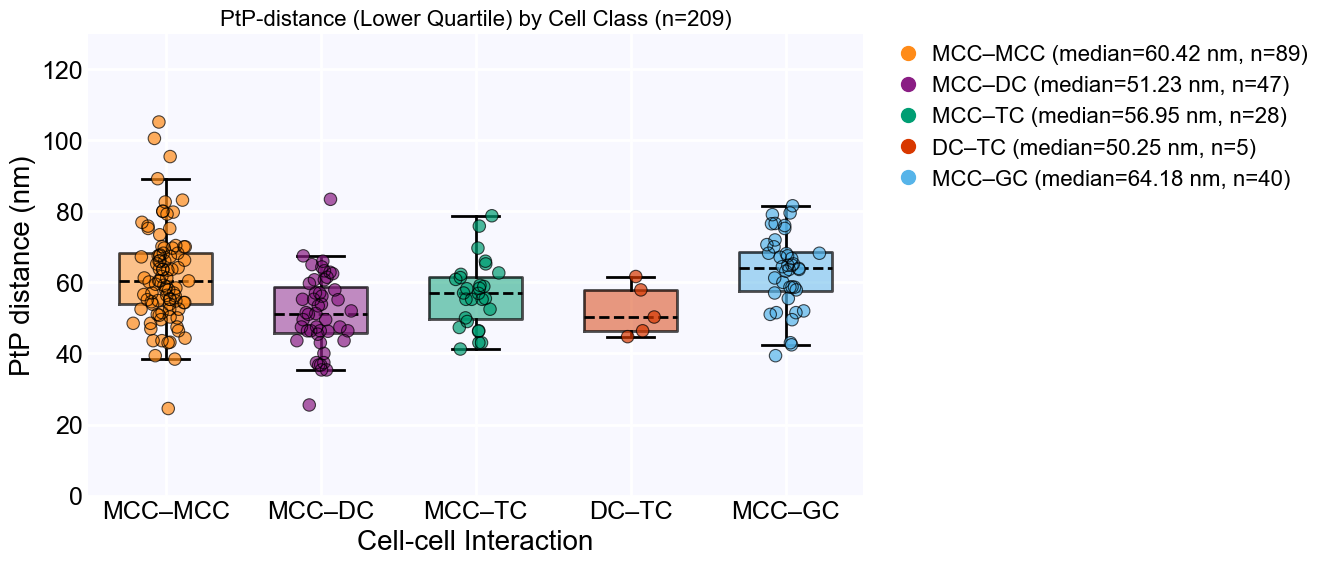

In [20]:
#Cell 2: Run only medians plot for Airway Cell classes

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import pandas as pd
from matplotlib.colors import to_rgba

pickle_path = os.path.join(output_base_dir, "lower_quartiles.pkl")

if not os.path.exists(pickle_path):
    raise FileNotFoundError(
        f"Pickle file not found:\n{pickle_path}\n"
        "Run Cell 1 once to generate it."
    )

df = pd.read_pickle(pickle_path) # loads the dataframe (df) wihtout having to process all vtks in cell 1 again

# ------------------------------
# Random seed for reproducible jitter
# ------------------------------
np.random.seed(42)

# ------------------------------
# Plot appearance
# ------------------------------
plot_width1 = 10
plot_height1 = 6
plot_background1 = "ghostwhite"
x_axis_limits1 = None
y_axis_limits1 = (0, 130)

title_fontsize1 = 16
axis_fontsize1 = 20
tick_fontsize1 = 18
legend_fontsize1 = 16

#Box plot parameters
point_size1 = 80
box_line_width = 2


# Grid appearance
grid_color1 = "white"
grid_linestyle1 = "-"

# ------------------------------
# Assign group based on filename
# ------------------------------
def classify_group(filename):
    if "mm" in filename.lower():
        return "MM"
    elif "dt" in filename.lower():
        return "DT"
    elif "mg" in filename.lower():
        return "MG"
    elif "md" in filename.lower():
        return "MD"
    elif "mt" in filename.lower():
        return "MT"
    else:
        return "other"

df["Group"] = df["ID"].apply(classify_group)

# group_colors = {"MM":"#AD0000", "DT": "#D83800", "MG": "#FF6C03", "MD": "#FFA824", "MT": "#FBD2B4", "other" : "#999999"}
group_colors = {"MM":"#ff8b18", "MD": "#8a1d84", "MT": "#009e73", "DT": "#d83800", "MG": "#56b4e9", "other" : "#999999"}
# ==============================
# NEW: Display labels for groups
# ==============================
group_display_labels = {
    "MM": "MCC–MCC",
    "MD": "MCC–DC",
    "MT": "MCC–AC2",
    "DT": "DC–AC2",
    "MG": "MCC–AC1"
}


# Desired group order
group_order = ["MM", "MD", "MT", "DT", "MG"]
group_order = [g for g in group_order if g in df["Group"].unique()]

# ------------------------------
# Box & whisker plot
# ------------------------------
fig, ax = plt.subplots(figsize=(plot_width1, plot_height1))
ax.tick_params(axis='both', which='major', length=0, labelsize=tick_fontsize1)
ax.set_facecolor(plot_background1)
ax.set_axisbelow(True)

legend_handles = []

box_face_alpha = 0.5
box_edge_alpha = 0.7

# Data for boxplot
box_data = [
    df.loc[df["Group"] == grp, "lower quartile distance [nm]"]
    for grp in group_order
]

# Create boxplot WITHOUT edges
box = ax.boxplot(
    box_data,
    labels=[group_display_labels.get(g, g) for g in group_order],
    patch_artist=True,
    widths=0.6,
    showfliers=False,
    medianprops=dict(color="black", linestyle="--", linewidth=box_line_width),
    boxprops=dict(edgecolor="none"),
    whiskerprops=dict(linewidth=box_line_width),
    capprops=dict(linewidth=box_line_width)
)

# Color boxes and draw custom edges
for i, (patch, grp) in enumerate(zip(box["boxes"], group_order), start=1):
    color = group_colors.get(grp, "#999999")

    # Face
    patch.set_facecolor(color)
    patch.set_alpha(box_face_alpha)

    # Get box bounds
    path = patch.get_path().vertices
    x = path[:, 0]
    y = path[:, 1]

    # Draw custom edge (rectangle)
    ax.plot(
        x, y,
        color="black",
        linewidth=box_line_width,
        alpha=box_edge_alpha,
        zorder=10
    )

    median_val = df.loc[df["Group"] == grp, "lower quartile distance [nm]"].median()

    n_grp = (df["Group"] == grp).sum()

    legend_handles.append(
        plt.Line2D(
            [0], [0],
            color=color,
            lw=0,
            marker="o",
            markersize=10,
            label=f"{group_display_labels.get(grp, grp)} "
                  f"(median={median_val:.2f} nm, n={n_grp})"
        )
    )


# ------------------------------
# Overlay individual data points (jittered)
# ------------------------------

for i, grp in enumerate(group_order, start=1):
    y_vals = df.loc[df["Group"] == grp, "lower quartile distance [nm]"]
    x_vals = np.random.normal(i, jitter_width, size=len(y_vals))

    # Face
    ax.scatter(
        x_vals,
        y_vals,
        color=group_colors.get(grp, "#999999"),
        alpha=0.7,
        s=point_size1,
        marker='o',
        edgecolor="None",
        zorder=10
    )

    # Edge
    ax.scatter(
        x_vals,
        y_vals,
        color="None",
        alpha=0.7,
        s=point_size1,
        marker='o',
        edgecolor="black",
        linewidth=0.8,
        zorder=11
    )
    

# ------------------------------
# Labels and title
# ------------------------------
ax.set_xlabel("Cell-cell Interaction", fontsize=axis_fontsize1)
ax.set_ylabel("MtM distance (nm)", fontsize=axis_fontsize1)
ax.set_xlim(x_axis_limits1)
ax.set_ylim(y_axis_limits1)
ax.set_title(
    f"MtM-distance (Lower Quartile) by Cell Class (n={len(df)})",
    fontsize=title_fontsize1
)

# ---------------------
# Legend positioning 
# ---------------------
ax.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(1.6, 1.02),
    handletextpad=0.1,
    frameon=False,
    fontsize=legend_fontsize1
)

# ------------------------------
# Grid and frame
# ------------------------------
ax.yaxis.grid(True, linestyle=grid_linestyle1, color=grid_color1, linewidth=2)
ax.xaxis.grid(False)

for spine in ax.spines.values():
    spine.set_visible(False)

# Grid and remove frame
ax.grid(True, linestyle=grid_linestyle1, color=grid_color1, linewidth=2, alpha=1, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# ------------------------------
# Preview first few rows
# ------------------------------
print("First few rows of lower quartile values:")
print(df[["ID", "lower quartile distance [nm]", "Group"]].head(10))

# ------------------------------
# Save lower quartile values to Excel
# ------------------------------
excel_output_path = os.path.join(output_base_dir, f"{input_vtk_basename}_lower_quartiles.xlsx")
df_to_save = df.drop(columns="y_random", errors='ignore')  # remove temporary column if exists
df_to_save.to_excel(excel_output_path, index=False)
print(f"Lower quartile values saved to: {excel_output_path}")
print(f"Loaded data from: {pickle_path}")

# ------------------------------
# Save figure
# ------------------------------
filename_base = f"{input_vtk_basename}_MtM-distance-plot_grouped"
fig.savefig(os.path.join(plots_dir, f"{filename_base}.png"), dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(plots_dir, f"{filename_base}.pdf"), dpi=300, bbox_inches="tight")
plt.show()
